1. Load data

In [17]:
import pickle

file_path = "../data/raw/WESAD/S2/S2.pkl"   # change to your file location

with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(data.keys())

dict_keys(['signal', 'label', 'subject'])


2.Filter ECG

In [18]:
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# ECG signal
ecg = data['signal']['chest']['ECG'].flatten()

# Sampling frequency of RespiBAN ECG
fs = 700

# Bandpass filter (0.5 - 40 Hz)
lowcut = 0.5
highcut = 40

nyquist = 0.5 * fs

b, a = butter(
    N=4,
    Wn=[lowcut/nyquist, highcut/nyquist],
    btype='band'
)

ecg_filtered = filtfilt(b, a, ecg)

print("Original ECG shape:", ecg.shape)
print("Filtered ECG shape:", ecg_filtered.shape)

Original ECG shape: (4255300,)
Filtered ECG shape: (4255300,)


Step 3: Compare Raw vs Filtered ECG

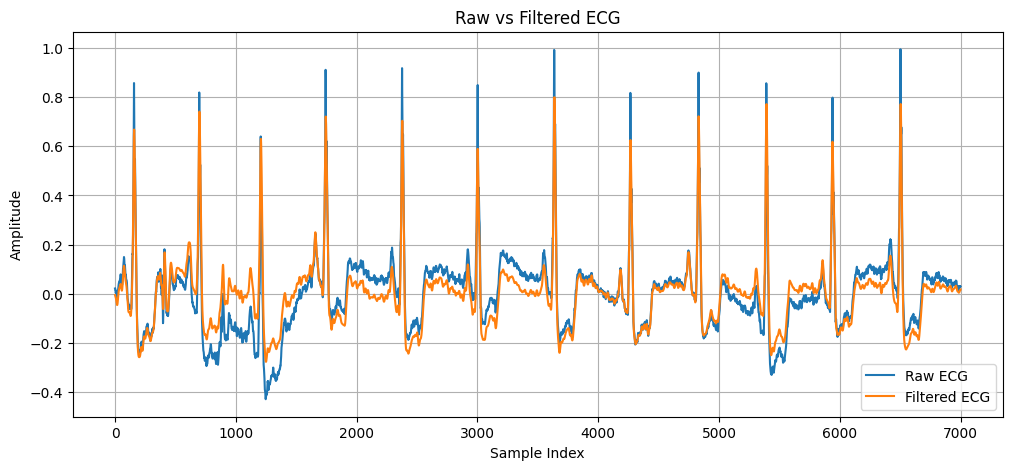

In [19]:
plt.figure(figsize=(12,5))

samples = 7000  # first 10 seconds

plt.plot(ecg[:samples], label='Raw ECG')
plt.plot(ecg_filtered[:samples], label='Filtered ECG')

plt.title('Raw vs Filtered ECG')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.show()

Step 4: Plot Only Filtered ECG

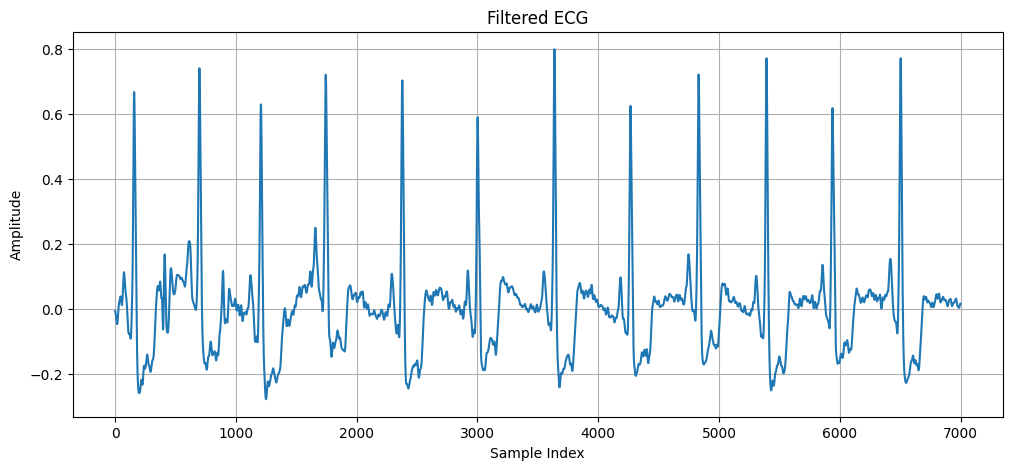

In [20]:
plt.figure(figsize=(12,5))

plt.plot(ecg_filtered[:7000])

plt.title('Filtered ECG')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)

plt.show()

DETECT FILTERATION 

1. Compare Mean and Standard Deviation

In [21]:
import numpy as np

print("RAW ECG")
print("Mean =", np.mean(ecg))
print("Std  =", np.std(ecg))

print("\nFILTERED ECG")
print("Mean =", np.mean(ecg_filtered))
print("Std  =", np.std(ecg_filtered))

RAW ECG
Mean = 0.001212244628837402
Std  = 0.15407729615295931

FILTERED ECG
Mean = 4.181065142104336e-08
Std  = 0.15099018286955915


2. Detect Baseline Drift

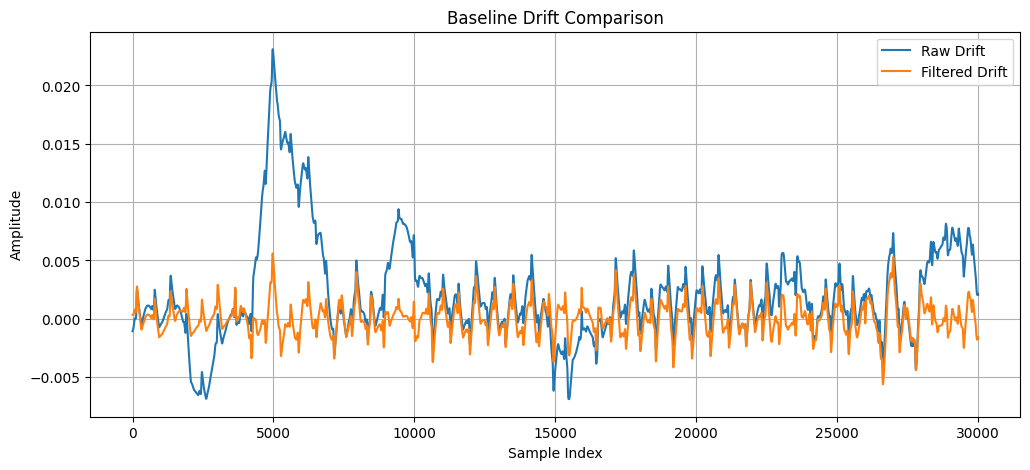

In [22]:
import numpy as np
import matplotlib.pyplot as plt

window = 7000  # 10 seconds

raw_drift = np.convolve(
    ecg.flatten(),
    np.ones(window)/window,
    mode='same'
)

filtered_drift = np.convolve(
    ecg_filtered.flatten(),
    np.ones(window)/window,
    mode='same'
)

plt.figure(figsize=(12,5))

plt.plot(raw_drift[:30000], label='Raw Drift')
plt.plot(filtered_drift[:30000], label='Filtered Drift')

plt.title('Baseline Drift Comparison')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.show()

3. Detect Spikes / Outliers

In [23]:
raw_z = np.abs(
    (ecg - np.mean(ecg)) /
    np.std(ecg)
)

filtered_z = np.abs(
    (ecg_filtered - np.mean(ecg_filtered)) /
    np.std(ecg_filtered)
)

raw_spikes = np.sum(raw_z > 3)
filtered_spikes = np.sum(filtered_z > 3)

print("Raw spikes:", raw_spikes)
print("Filtered spikes:", filtered_spikes)

Raw spikes: 102518
Filtered spikes: 109345


4. Estimate High-Frequency Noise

In [24]:
noise_raw = np.std(np.diff(ecg.flatten()))
noise_filtered = np.std(np.diff(ecg_filtered.flatten()))

print("Raw noise estimate:", noise_raw)
print("Filtered noise estimate:", noise_filtered)

Raw noise estimate: 0.015717772282863838
Filtered noise estimate: 0.010164434819758315


5. Create a Summary Table

In [25]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Mean",
        "Std",
        "Spikes (>3σ)",
        "Noise Estimate"
    ],
    "Raw": [
        np.mean(ecg),
        np.std(ecg),
        raw_spikes,
        noise_raw
    ],
    "Filtered": [
        np.mean(ecg_filtered),
        np.std(ecg_filtered),
        filtered_spikes,
        noise_filtered
    ]
})

print(results)

           Metric            Raw      Filtered
0            Mean       0.001212  4.181065e-08
1             Std       0.154077  1.509902e-01
2    Spikes (>3σ)  102518.000000  1.093450e+05
3  Noise Estimate       0.015718  1.016443e-02


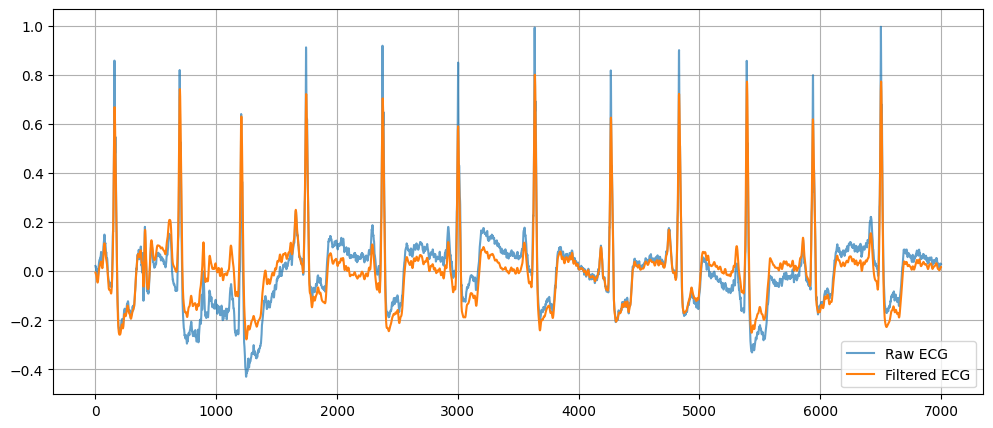

In [26]:
plt.figure(figsize=(12,5))

plt.plot(ecg[:7000], label='Raw ECG', alpha=0.7)
plt.plot(ecg_filtered[:7000], label='Filtered ECG')

plt.legend()
plt.grid(True)
plt.show()